# Forest Cover Type Classification with a Multilayer Perceptron

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Redes Neurais<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** July 6, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Predicting forest cover type is a multiclass classification problem grounded in ecological land management. Given cartographic and geographic measurements of a 30x30 meter forested land patch in the Roosevelt National Forest of Colorado, the task is to identify which of seven tree cover types is present. This classification supports forest management, biodiversity monitoring, and wildfire risk assessment.

**Task Type:**  
Supervised Learning, Multiclass Classification

**Objective:**  
Train and evaluate a Multilayer Perceptron (MLP) on the Covertype dataset, comparing three training strategies: no class balancing, undersampling, and oversampling.

**Primary Evaluation Metrics:**  
Accuracy, F1-Score Micro, and F1-Score Macro

**Success Criteria:**  
A model achieving F1-Macro above 0.80 on the test set is considered successful, given the strong class imbalance present in the dataset.

## 2. Setup & Imports

In [1]:
import os
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings
import random

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Environment ready")
print("Pandas version:", pd.__version__)
print("PyTorch version:", torch.__version__)
if torch.cuda.is_available():
    print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0)})")
else:
    print(f"Device: {DEVICE} (no CUDA device found)")

Environment ready
Pandas version: 3.0.1
PyTorch version: 2.11.0+cu128
Device: cuda (NVIDIA GeForce RTX 5070)


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[UCI Machine Learning Repository — Covertype Dataset](https://archive.ics.uci.edu/dataset/31/covertype)

**Description:**  
The Covertype dataset contains cartographic variables describing forested land patches in the Roosevelt National Forest, Colorado. Each row represents a 30x30 meter patch characterized by elevation, terrain geometry, proximity to water and road infrastructure, hillshade indices, and binary encodings of wilderness area and soil type designations. The raw file has no header; column names are assigned programmatically. The data is split into training (70%), validation (15%), and test (15%) sets using stratified sampling to preserve class proportions.

**Features:**

| Feature | Count | Type | Description |
|--------------|-------|------|-------------|
| `Elevation` | 1 | Numerical | Elevation in meters |
| `Aspect` | 1 | Numerical | Aspect in degrees azimuth |
| `Slope` | 1 | Numerical | Slope in degrees |
| `Horizontal_Distance_To_Hydrology` | 1 | Numerical | Horizontal distance to nearest water feature (m) |
| `Vertical_Distance_To_Hydrology` | 1 | Numerical | Vertical distance to nearest water feature (m) |
| `Horizontal_Distance_To_Roadways` | 1 | Numerical | Horizontal distance to nearest roadway (m) |
| `Hillshade_9am / Noon / 3pm` | 3 | Numerical | Hillshade index at three times of day (0-255) |
| `Horizontal_Distance_To_Fire_Points` | 1 | Numerical | Horizontal distance to nearest ignition point (m) |
| `Wilderness_Area1-4` | 4 | Binary | One-hot encoded wilderness area designation |
| `Soil_Type1-40` | 40 | Binary | One-hot encoded soil type classification |

**Unit of Analysis:**  
A 30x30 meter land patch in the Roosevelt National Forest, Colorado

**Target Variable:**  
`Cover_Type`, an integer label from 1 to 7 representing the dominant forest cover type

| Class | Cover Type |
|-------|------------|
| 1 | Spruce/Fir |
| 2 | Lodgepole Pine |
| 3 | Ponderosa Pine |
| 4 | Cottonwood/Willow |
| 5 | Aspen |
| 6 | Douglas-fir |
| 7 | Krummholz |

In [2]:
import gzip
import shutil

DATA_DIR = os.path.expanduser('~/dataset/')
DATASET_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz'

GZ_FILE = os.path.join(DATA_DIR, 'covtype.data.gz')
OUT_FILE = os.path.join(DATA_DIR, 'covtype.data')

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(GZ_FILE) and not os.path.exists(OUT_FILE):
    subprocess.run(
        ['wget', '-O', GZ_FILE, DATASET_URL],
        check=True,
    )
    print('Download completed.')
else:
    print('Dataset already downloaded.')

if os.path.exists(GZ_FILE) and not os.path.exists(OUT_FILE):
    with gzip.open(GZ_FILE, 'rb') as f_in:
        with open(OUT_FILE, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('Extraction completed.')

print('Dataset ready at:', OUT_FILE)

Dataset already downloaded.
Dataset ready at: /home/guto/dataset/covtype.data


In [3]:
COLUMN_NAMES = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways", "Hillshade_9am",
    "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
    *[f"Wilderness_Area{i}" for i in range(1, 5)],
    *[f"Soil_Type{i}" for i in range(1, 41)],
    "Cover_Type"
]

df_raw = pd.read_csv(OUT_FILE, header=None, names=COLUMN_NAMES)

print("Full dataset shape:", df_raw.shape)

# Stratified split: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(
    df_raw, test_size=0.30, random_state=SEED, stratify=df_raw["Cover_Type"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["Cover_Type"]
)

print("\nDataset sizes after split:")
print(f"  Train:      {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"  Validation: {val_df.shape[0]:,} rows x {val_df.shape[1]} columns")
print(f"  Test:       {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")

display(train_df.head())

print("\nData types:")
display(train_df.dtypes)

print("\nMissing values (train):", train_df.isna().sum().sum())

print("\nSummary statistics:")
display(train_df.describe())

Full dataset shape: (581012, 55)

Dataset sizes after split:
  Train:      406,708 rows x 55 columns
  Validation: 87,152 rows x 55 columns
  Test:       87,152 rows x 55 columns


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
244336,2823,30,29,162,46,1150,198,165,87,1746,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
518278,3323,335,15,618,76,886,185,218,172,1173,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
151614,2822,346,14,108,20,2427,192,217,162,1931,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2
85676,2839,153,7,0,0,4001,229,241,144,3362,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
419952,3172,211,21,234,80,3154,198,254,184,977,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1



Data types:


Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64
Soil_Type9                      


Missing values (train): 0

Summary statistics:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000,406708.000000
mean,2959.525768,155.761040,14.109226,269.364384,46.450003,2350.544927,212.129309,223.317643,142.543395,1978.027932,0.448172,0.051526,0.436583,0.063719,0.005235,0.012901,0.008436,0.021290,0.002761,0.011401,0.000182,0.000322,0.001960,0.056119,0.021399,0.051587,0.030014,0.000976,0.000002,0.004945,0.005842,0.003260,0.006948,0.016034,0.001483,0.057287,0.099255,0.036491,0.000792,0.004372,0.001842,0.001598,0.198285,0.051671,0.044191,0.090512,0.078054,0.002746,0.003287,0.000207,0.000511,0.026631,0.023919,0.015252,2.051472
std,280.117503,111.956087,7.487878,212.379553,58.301650,1558.689602,26.766045,19.769991,38.285822,1322.353037,0.497307,0.221068,0.495963,0.244252,0.072162,0.112848,0.091460,0.144351,0.052475,0.106167,0.013488,0.017944,0.044224,0.230151,0.144709,0.221193,0.170626,0.031228,0.001568,0.070144,0.076210,0.057006,0.083068,0.125605,0.038477,0.232390,0.299005,0.187508,0.028126,0.065974,0.042875,0.039946,0.398708,0.221362,0.205520,0.286914,0.268256,0.052335,0.057241,0.014370,0.022609,0.161002,0.152797,0.122553,1.396507
min,1860.000000,0.000000,0.000000,0.000000,-166.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1998.000000,218.000000,226.000000,143.000000,1710.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000

## 4. Exploratory Data Analysis (EDA)

Goals:

- Assess class balance in the training set
- Understand distributions of the ten numerical cartographic features
- Examine pairwise correlations among numerical features
- Identify the main modeling challenges

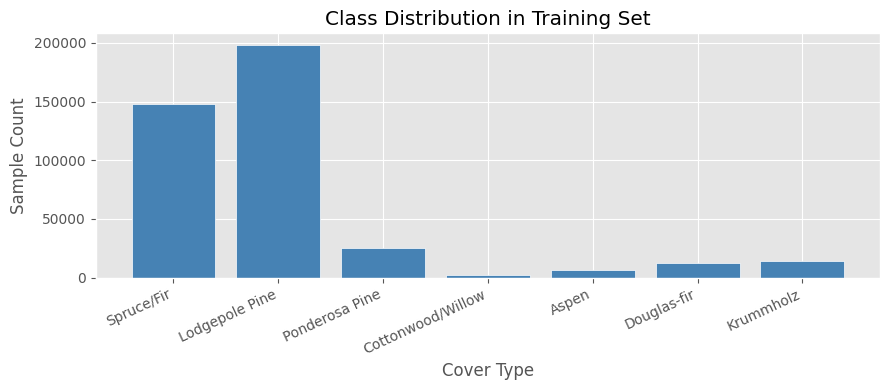

Class distribution:
  1 - Spruce/Fir          : 148,288 (36.5%)
  2 - Lodgepole Pine      : 198,310 (48.8%)
  3 - Ponderosa Pine      :  25,028 (6.2%)
  4 - Cottonwood/Willow   :   1,923 (0.5%)
  5 - Aspen               :   6,645 (1.6%)
  6 - Douglas-fir         :  12,157 (3.0%)
  7 - Krummholz           :  14,357 (3.5%)


In [4]:
COVER_TYPE_LABELS = {
    1: "Spruce/Fir",
    2: "Lodgepole Pine",
    3: "Ponderosa Pine",
    4: "Cottonwood/Willow",
    5: "Aspen",
    6: "Douglas-fir",
    7: "Krummholz"
}

class_counts = train_df["Cover_Type"].value_counts().sort_index()
class_labels = [COVER_TYPE_LABELS[i] for i in class_counts.index]

plt.figure(figsize=(9, 4))
plt.bar(class_labels, class_counts.values, color="steelblue", edgecolor="white")
plt.title("Class Distribution in Training Set")
plt.xlabel("Cover Type")
plt.ylabel("Sample Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print("Class distribution:")
for class_id, count in class_counts.items():
    pct = count / class_counts.sum() * 100
    label = COVER_TYPE_LABELS[class_id]
    print(f"  {class_id} - {label:20s}: {count:7,} ({pct:.1f}%)")

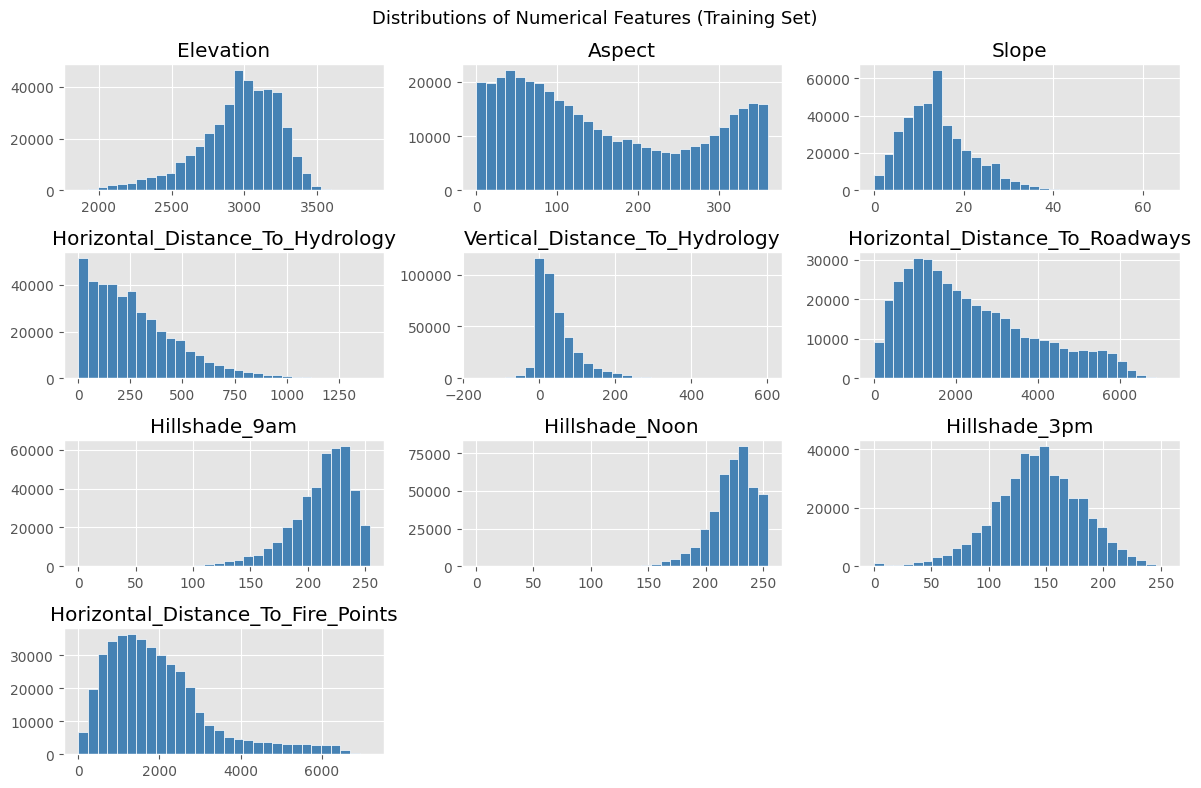

In [5]:
NUM_FEATURES = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways", "Hillshade_9am",
    "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

train_df[NUM_FEATURES].hist(figsize=(12, 8), bins=30, edgecolor="white", color="steelblue")
plt.suptitle("Distributions of Numerical Features (Training Set)", fontsize=13)
plt.tight_layout()
plt.show()

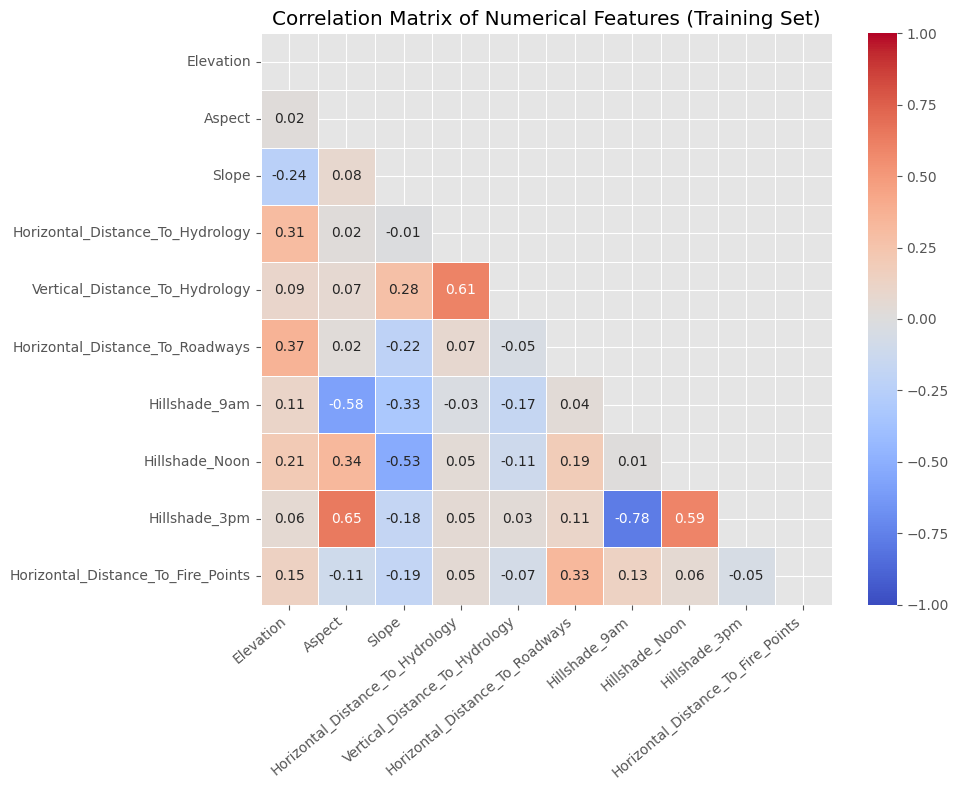

In [6]:
corr = train_df[NUM_FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix of Numerical Features (Training Set)")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.1 EDA Findings

- The training set is strongly imbalanced. Classes 1 (Spruce/Fir) and 2 (Lodgepole Pine) together dominate the dataset, while classes 3 through 7 are substantially underrepresented. Class 4 (Cottonwood/Willow) is the rarest by a wide margin.
- Elevation shows a multi-modal distribution reflecting the distinct elevation bands naturally occupied by different cover types. It is expected to be the most discriminative single feature.
- Distance features (to hydrology, roadways, and fire points) are right-skewed, with high density at short distances and a long right tail corresponding to remote patches.
- Hillshade indices are approximately unimodal. Hillshade_Noon has the narrowest spread, while Hillshade_9am shows greater variability across aspect orientations.
- All 44 binary features (wilderness areas and soil types) are already one-hot encoded and require no further transformation.

The class imbalance is the central modeling challenge.

## 5. Preprocessing & Feature Engineering

Operations performed:

- Separation of features and the target variable across all three splits
- Three versions of the training set: original (no balancing), undersampled, and oversampled
- Each strategy uses its own `StandardScaler`, fitted **on that strategy's training data** to ensure scaling statistics reflect the actual distribution the model trains on
- Validation and test sets are scaled with the corresponding strategy's scaler to maintain consistency within each experiment

No missing value imputation or categorical encoding is required; the dataset is fully numeric and complete.

In [7]:
TARGET_COL = "Cover_Type"

X_train = train_df.drop(TARGET_COL, axis=1)
y_train = train_df[TARGET_COL]

X_val = val_df.drop(TARGET_COL, axis=1)
y_val = val_df[TARGET_COL]

X_test = test_df.drop(TARGET_COL, axis=1)
y_test = test_df[TARGET_COL]

print("Feature/target dimensions:")
print(f"  Train:      X={X_train.shape}, y={y_train.shape}")
print(f"  Validation: X={X_val.shape}, y={y_val.shape}")
print(f"  Test:       X={X_test.shape}, y={y_test.shape}")

Feature/target dimensions:
  Train:      X=(406708, 54), y=(406708,)
  Validation: X=(87152, 54), y=(87152,)
  Test:       X=(87152, 54), y=(87152,)


In [8]:
def undersample(X, y, seed=SEED):
    """Downsample all classes to the size of the smallest class."""
    target_col = y.name
    df = pd.concat([X, y], axis=1)
    min_size = df[target_col].value_counts().min()
    balanced = pd.concat([
        df[df[target_col] == c].sample(min_size, random_state=seed)
        for c in df[target_col].unique()
    ]).sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced.drop(columns=[target_col]), balanced[target_col]


def oversample(X, y, seed=SEED):
    """Upsample all classes to the size of the largest class (with replacement)."""
    target_col = y.name
    df = pd.concat([X, y], axis=1)
    max_size = df[target_col].value_counts().max()
    balanced = pd.concat([
        resample(df[df[target_col] == c], n_samples=max_size, replace=True, random_state=seed)
        for c in df[target_col].unique()
    ]).sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced.drop(columns=[target_col]), balanced[target_col]

In [9]:
# --- Balanced training sets ---
X_train_us, y_train_us = undersample(X_train, y_train, seed=SEED)
X_train_os, y_train_os = oversample(X_train, y_train, seed=SEED)

# --- Strategy-specific scalers (each fitted on its own training data) ---

# Strategy 1: No balancing — scaler fitted on original training set
scaler_nb = StandardScaler()
X_train_nb_scaled = scaler_nb.fit_transform(X_train)
X_val_nb_scaled   = scaler_nb.transform(X_val)
X_test_nb_scaled  = scaler_nb.transform(X_test)

# Strategy 2: Undersampling — scaler fitted on undersampled training set
scaler_us = StandardScaler()
X_train_us_scaled = scaler_us.fit_transform(X_train_us)
X_val_us_scaled   = scaler_us.transform(X_val)
X_test_us_scaled  = scaler_us.transform(X_test)

# Strategy 3: Oversampling — scaler fitted on oversampled training set
scaler_os = StandardScaler()
X_train_os_scaled = scaler_os.fit_transform(X_train_os)
X_val_os_scaled   = scaler_os.transform(X_val)
X_test_os_scaled  = scaler_os.transform(X_test)

print("Training set sizes per strategy:")
print(f"  No balancing:  {X_train.shape[0]:>9,} samples")
print(f"  Undersampling: {X_train_us.shape[0]:>9,} samples")
print(f"  Oversampling:  {X_train_os.shape[0]:>9,} samples")

Training set sizes per strategy:
  No balancing:    406,708 samples
  Undersampling:    13,461 samples
  Oversampling:  1,388,170 samples


## 6. Model Training

In [10]:
hyperparams = {
    "input_dim": 54,
    "hidden_dims": [64, 32],
    "output_dim": 7,
    "lr": 0.001,
    "weight_decay": 1e-5,
    "n_epochs": 30,
    "batch_size": 64,
}

print("Hyperparameters:")
for k, v in hyperparams.items():
    print(f"  {k}: {v}")

Hyperparameters:
  input_dim: 54
  hidden_dims: [64, 32]
  output_dim: 7
  lr: 0.001
  weight_decay: 1e-05
  n_epochs: 30
  batch_size: 64


In [11]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super(MLP, self).__init__()
        dims = [input_dim] + hidden_dims
        layers = []
        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(dims[-1], output_dim))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

In [14]:
def evaluate(model, dataloader):
    """Evaluate the model on a DataLoader; returns accuracy, F1 scores, confusion matrix, and raw predictions."""
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(DEVICE)
            preds = torch.argmax(model(X_batch), dim=1).cpu().numpy()
            y_true.extend(y_batch.numpy())
            y_pred.extend(preds)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred
    }


def make_loaders(X_train_scaled, y_train_ser, X_val_scaled, y_val_ser, X_test_scaled, y_test_ser):
    """Build train, validation and test DataLoaders for a given scaling."""
    batch_size = hyperparams["batch_size"]

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train_scaled, dtype=torch.float32),
            torch.tensor(y_train_ser.values, dtype=torch.long) - 1
        ),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_val_scaled, dtype=torch.float32),
            torch.tensor(y_val_ser.values, dtype=torch.long) - 1
        ),
        batch_size=batch_size
    )
    test_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_test_scaled, dtype=torch.float32),
            torch.tensor(y_test_ser.values, dtype=torch.long) - 1
        ),
        batch_size=batch_size
    )
    return train_loader, val_loader, test_loader


def train_model(train_loader, val_loader):
    """Instantiate and train an MLP; returns the trained model and a per-epoch log DataFrame."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    torch.manual_seed(SEED)
    model = MLP(
        input_dim=hyperparams["input_dim"],
        hidden_dims=hyperparams["hidden_dims"],
        output_dim=hyperparams["output_dim"]
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=hyperparams["lr"],
        weight_decay=hyperparams["weight_decay"]
    )
    log = []
    n_epochs = hyperparams["n_epochs"]

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        val_metrics = evaluate(model, val_loader)
        log.append({
            "epoch": epoch + 1,
            "loss": epoch_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_micro": val_metrics["f1_micro"],
            "val_f1_macro": val_metrics["f1_macro"]
        })

        print(
            f"  === Epoch {epoch + 1:02d}/{n_epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"F1 Macro: {val_metrics['f1_macro']:.4f} ===",
            flush=True
        )

    return model, pd.DataFrame(log)

### 6.1 Strategy 1: No Balancing

The model is trained on the original imbalanced training set without any resampling. This serves as the baseline. The class imbalance is left intact, so the model is expected to perform well on the dominant classes (Spruce/Fir, Lodgepole Pine) but struggle on the minority classes, which will be reflected in a lower F1-Macro score.

In [15]:
train_loader_nb, val_loader_nb, test_loader_nb = make_loaders(
    X_train_nb_scaled, y_train,
    X_val_nb_scaled, y_val,
    X_test_nb_scaled, y_test
)

print(f"Training without balancing ({len(train_loader_nb.dataset):,} samples):")
model_nb, log_nb = train_model(train_loader_nb, val_loader_nb)

Training without balancing (406,708 samples):
  === Epoch 01/30 | Loss: 3707.3036 | Val Acc: 0.7715 | F1 Macro: 0.6020 ===
  === Epoch 02/30 | Loss: 3128.9761 | Val Acc: 0.7903 | F1 Macro: 0.6632 ===
  === Epoch 03/30 | Loss: 2895.8080 | Val Acc: 0.8097 | F1 Macro: 0.6922 ===
  === Epoch 04/30 | Loss: 2751.3687 | Val Acc: 0.8221 | F1 Macro: 0.7216 ===
  === Epoch 05/30 | Loss: 2645.0511 | Val Acc: 0.8257 | F1 Macro: 0.7198 ===
  === Epoch 06/30 | Loss: 2572.8824 | Val Acc: 0.8321 | F1 Macro: 0.7461 ===
  === Epoch 07/30 | Loss: 2510.5601 | Val Acc: 0.8304 | F1 Macro: 0.7377 ===
  === Epoch 08/30 | Loss: 2461.9443 | Val Acc: 0.8410 | F1 Macro: 0.7547 ===
  === Epoch 09/30 | Loss: 2421.1124 | Val Acc: 0.8377 | F1 Macro: 0.7643 ===
  === Epoch 10/30 | Loss: 2385.4930 | Val Acc: 0.8384 | F1 Macro: 0.7566 ===
  === Epoch 11/30 | Loss: 2350.9012 | Val Acc: 0.8471 | F1 Macro: 0.7669 ===
  === Epoch 12/30 | Loss: 2323.0350 | Val Acc: 0.8433 | F1 Macro: 0.7512 ===
  === Epoch 13/30 | Loss: 2296

### 6.2 Strategy 2: Undersampling

Majority classes are downsampled to match the size of the smallest class. This results in a much smaller but perfectly balanced training set. The trade-off is that a large portion of the original training data is discarded, which may reduce the model's ability to learn fine-grained patterns in the majority classes. The expected benefit is improved recall on minority classes and a higher F1-Macro score.

In [16]:
train_loader_us, val_loader_us, test_loader_us = make_loaders(
    X_train_us_scaled, y_train_us,
    X_val_us_scaled, y_val,
    X_test_us_scaled, y_test
)

print(f"Training with undersampling ({len(train_loader_us.dataset):,} samples):")
model_us, log_us = train_model(train_loader_us, val_loader_us)

Training with undersampling (13,461 samples):
  === Epoch 01/30 | Loss: 253.0248 | Val Acc: 0.5531 | F1 Macro: 0.4569 ===
  === Epoch 02/30 | Loss: 166.7470 | Val Acc: 0.5831 | F1 Macro: 0.4851 ===
  === Epoch 03/30 | Loss: 151.4733 | Val Acc: 0.5951 | F1 Macro: 0.5061 ===
  === Epoch 04/30 | Loss: 142.5104 | Val Acc: 0.5922 | F1 Macro: 0.4967 ===
  === Epoch 05/30 | Loss: 136.8030 | Val Acc: 0.6124 | F1 Macro: 0.5252 ===
  === Epoch 06/30 | Loss: 131.3645 | Val Acc: 0.5979 | F1 Macro: 0.5261 ===
  === Epoch 07/30 | Loss: 128.1802 | Val Acc: 0.5951 | F1 Macro: 0.5038 ===
  === Epoch 08/30 | Loss: 124.9577 | Val Acc: 0.6205 | F1 Macro: 0.5328 ===
  === Epoch 09/30 | Loss: 122.0761 | Val Acc: 0.6109 | F1 Macro: 0.5292 ===
  === Epoch 10/30 | Loss: 119.7471 | Val Acc: 0.6138 | F1 Macro: 0.5271 ===
  === Epoch 11/30 | Loss: 117.2937 | Val Acc: 0.6403 | F1 Macro: 0.5496 ===
  === Epoch 12/30 | Loss: 115.8722 | Val Acc: 0.6553 | F1 Macro: 0.5647 ===
  === Epoch 13/30 | Loss: 113.6789 | Val A

### 6.3 Strategy 3: Oversampling

Minority classes are upsampled with replacement to match the size of the largest class. This results in a larger training set where all classes are equally represented. The trade-off is that duplicated samples may cause the model to overfit to minority class patterns. The expected benefit is improved recall on minority classes while retaining full majority-class data.

In [17]:
train_loader_os, val_loader_os, test_loader_os = make_loaders(
    X_train_os_scaled, y_train_os,
    X_val_os_scaled, y_val,
    X_test_os_scaled, y_test
)

print(f"Training with oversampling ({len(train_loader_os.dataset):,} samples):")
model_os, log_os = train_model(train_loader_os, val_loader_os)

Training with oversampling (1,388,170 samples):
  === Epoch 01/30 | Loss: 10004.9061 | Val Acc: 0.7374 | F1 Macro: 0.6809 ===
  === Epoch 02/30 | Loss: 7499.9349 | Val Acc: 0.7577 | F1 Macro: 0.7039 ===
  === Epoch 03/30 | Loss: 6814.5152 | Val Acc: 0.7741 | F1 Macro: 0.7255 ===
  === Epoch 04/30 | Loss: 6379.6076 | Val Acc: 0.7792 | F1 Macro: 0.7374 ===
  === Epoch 05/30 | Loss: 6076.3492 | Val Acc: 0.7908 | F1 Macro: 0.7570 ===
  === Epoch 06/30 | Loss: 5860.1796 | Val Acc: 0.7956 | F1 Macro: 0.7562 ===
  === Epoch 07/30 | Loss: 5705.8883 | Val Acc: 0.7801 | F1 Macro: 0.7451 ===
  === Epoch 08/30 | Loss: 5588.7322 | Val Acc: 0.7977 | F1 Macro: 0.7718 ===
  === Epoch 09/30 | Loss: 5469.1962 | Val Acc: 0.8020 | F1 Macro: 0.7663 ===
  === Epoch 10/30 | Loss: 5376.8825 | Val Acc: 0.8091 | F1 Macro: 0.7760 ===
  === Epoch 11/30 | Loss: 5295.8738 | Val Acc: 0.8076 | F1 Macro: 0.7760 ===
  === Epoch 12/30 | Loss: 5229.2957 | Val Acc: 0.8074 | F1 Macro: 0.7634 ===
  === Epoch 13/30 | Loss: 5

## 7. Model Evaluation & Strategy Comparison

All three models are evaluated on their respective test sets (each scaled with the strategy's own scaler). The comparison includes:

- Per-class precision, recall, and F1-score via classification reports
- Side-by-side confusion matrices
- Overlaid training curves (all 3 strategies on the same plot per metric)
- Summary metrics table

In [19]:
STRATEGY_NAMES = ["No Balancing", "Undersampling", "Oversampling"]
models       = [model_nb,      model_us,        model_os]
test_loaders = [test_loader_nb, test_loader_us,  test_loader_os]
target_names = [COVER_TYPE_LABELS[i] for i in range(1, 8)]

test_results = {}
for name, model, loader in zip(STRATEGY_NAMES, models, test_loaders):
    test_results[name] = evaluate(model, loader)

# Classification reports
for name, metrics in test_results.items():
    print(f"Classification Report — {name}:")
    print(classification_report(metrics["y_true"], metrics["y_pred"], target_names=target_names))

# Summary table
summary_df = pd.DataFrame([
    {
        "Strategy": name,
        "Accuracy": round(m["accuracy"], 4),
        "F1 Micro": round(m["f1_micro"], 4),
        "F1 Macro": round(m["f1_macro"], 4)
    }
    for name, m in test_results.items()
])
print("Summary (Test Set):")
display(summary_df)

Classification Report — No Balancing:
                   precision    recall  f1-score   support

       Spruce/Fir       0.86      0.85      0.86     31776
   Lodgepole Pine       0.88      0.89      0.88     42496
   Ponderosa Pine       0.82      0.90      0.86      5363
Cottonwood/Willow       0.80      0.70      0.75       412
            Aspen       0.79      0.51      0.62      1424
      Douglas-fir       0.76      0.68      0.72      2605
        Krummholz       0.82      0.93      0.87      3076

         accuracy                           0.86     87152
        macro avg       0.82      0.78      0.79     87152
     weighted avg       0.86      0.86      0.86     87152

Classification Report — Undersampling:
                   precision    recall  f1-score   support

       Spruce/Fir       0.70      0.74      0.72     31776
   Lodgepole Pine       0.83      0.60      0.70     42496
   Ponderosa Pine       0.73      0.72      0.73      5363
Cottonwood/Willow       0.40      

,Strategy,Accuracy,F1 Micro,F1 Macro
0,No Balancing,0.8631,0.8631,0.7934
1,Undersampling,0.6850,0.6850,0.6118
2,Oversampling,0.8280,0.8280,0.8085


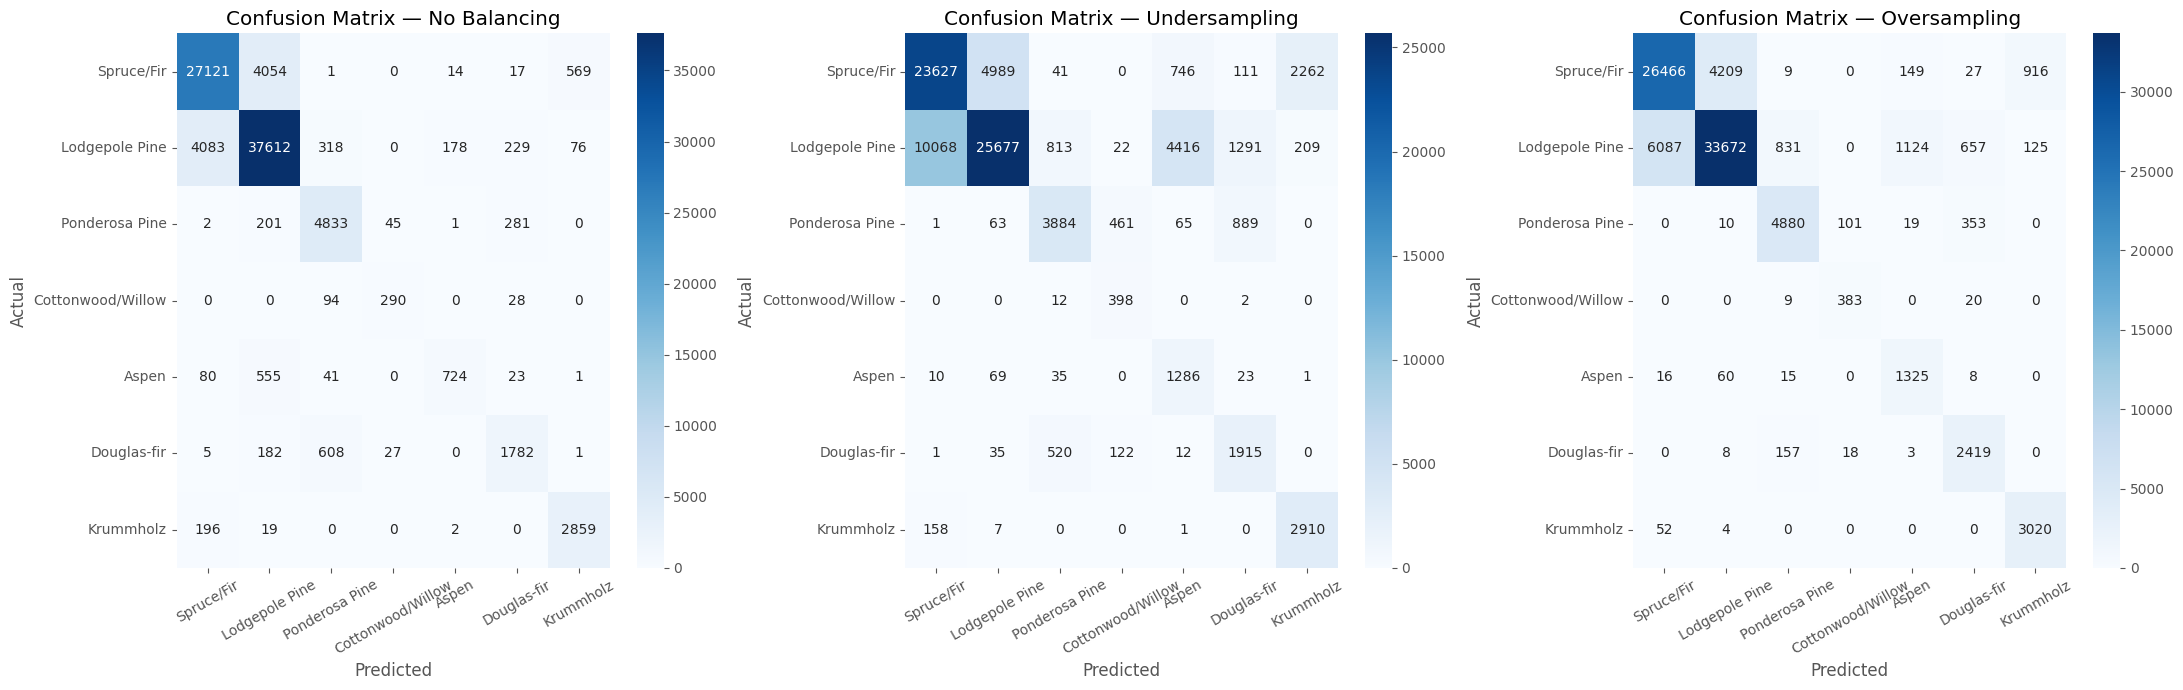

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, metrics) in zip(axes, test_results.items()):
    sns.heatmap(
        metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
        xticklabels=target_names, yticklabels=target_names, ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

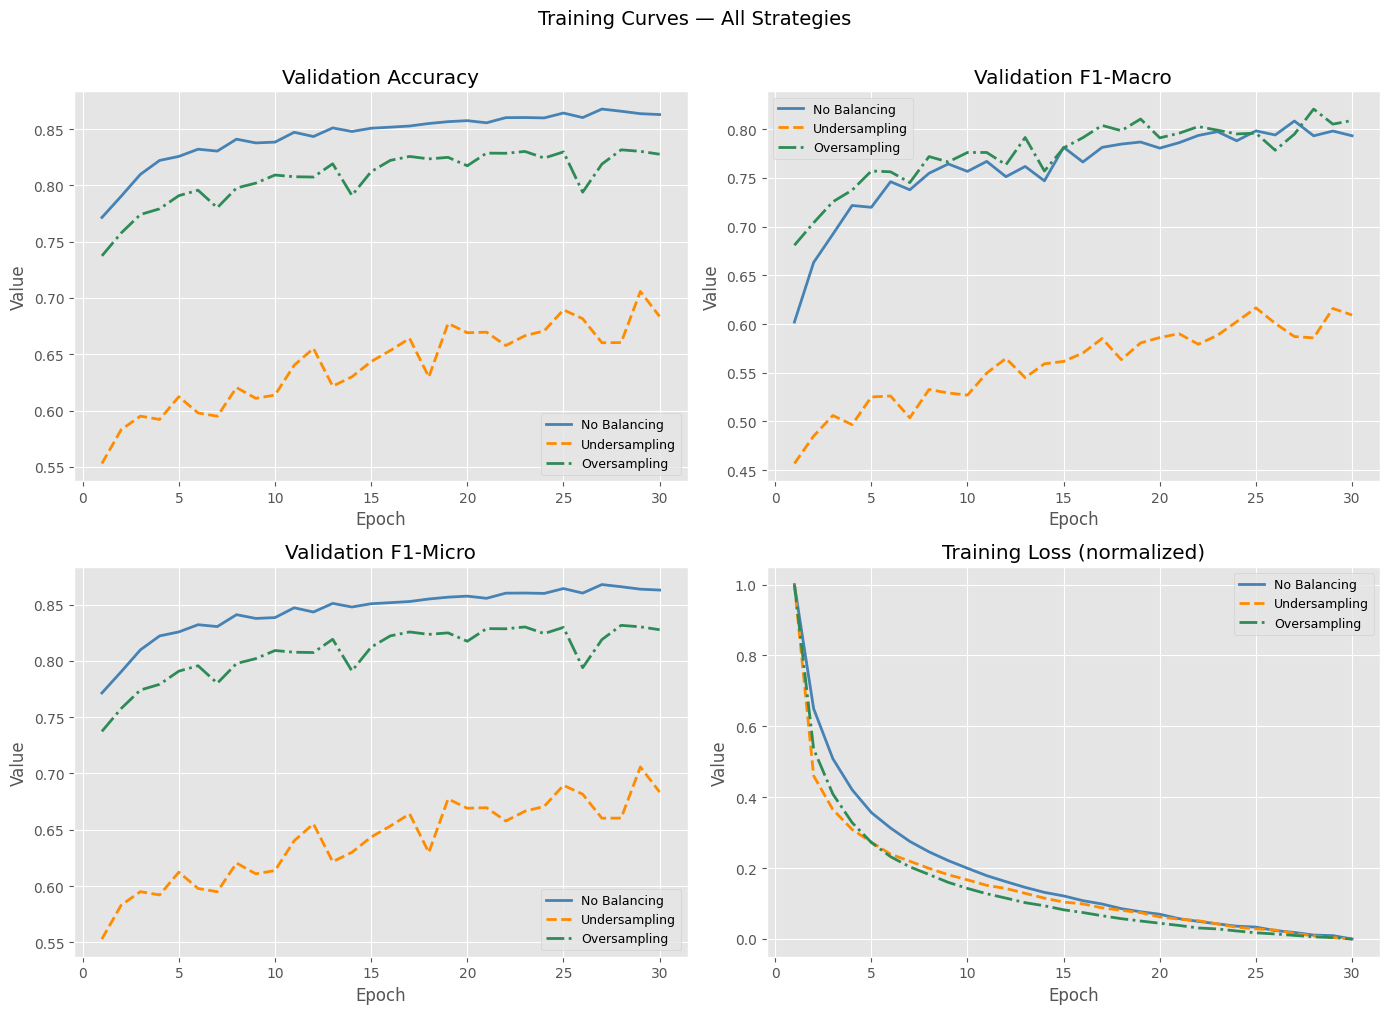

In [21]:
logs = [log_nb, log_us, log_os]

# Color and line style per strategy
strategy_styles = {
    "No Balancing":  {"color": "steelblue",  "ls": "-"},
    "Undersampling": {"color": "darkorange",  "ls": "--"},
    "Oversampling":  {"color": "seagreen",    "ls": "-."},
}

# Metrics to plot (col name, display title)
metrics_to_plot = [
    ("val_accuracy", "Validation Accuracy"),
    ("val_f1_macro", "Validation F1-Macro"),
    ("val_f1_micro", "Validation F1-Micro"),
    ("loss",         "Training Loss (normalized)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics_to_plot):
    for name, log in zip(STRATEGY_NAMES, logs):
        style = strategy_styles[name]
        if col == "loss":
            loss_arr = log["loss"].values
            values = (loss_arr - loss_arr.min()) / (loss_arr.max() - loss_arr.min())
        else:
            values = log[col].values
        ax.plot(log["epoch"], values,
                color=style["color"], linestyle=style["ls"],
                linewidth=2, label=name)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")
    ax.legend(fontsize=9)

plt.suptitle("Training Curves — All Strategies", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Conclusions & Next Steps

**Key Findings:**
- The dataset contains 581,012 samples across 7 forest cover types with pronounced class imbalance: Lodgepole Pine (class 2) accounts for 48.8% of training samples and Spruce/Fir (class 1) for 36.5%, while Cottonwood/Willow (class 4) represents only 0.5% (1,923 samples). This imbalance directly shapes the precision-recall tradeoffs observed across all three training strategies.
- Elevation exhibits a multi-modal distribution that maps naturally to the elevation bands occupied by distinct cover types, making it the most discriminative continuous feature. Distance features (to hydrology, roadways, and fire points) and hillshade indices provide secondary terrain signal, while the 40 binary soil-type indicators are extremely sparse, with most columns having a mean below 0.05.
- The model is a two-hidden-layer MLP (54 inputs, 64, 32 hidden units, 7 outputs), trained with Adam (lr=0.001, weight_decay=1e-5), batch size 64, for 30 epochs. Three independent instances of this architecture were trained under three class-balancing strategies to isolate the effect of resampling on performance, with each strategy using its own StandardScaler fitted exclusively on its training split.

**Model Performance vs Success Criteria:**
Results on the held-out test set (87,152 samples):

| Strategy      | Accuracy | F1 Macro | F1 Micro |
|---------------|----------|----------|----------|
| No Balancing  | 0.8631   | 0.7934   | 0.8631   |
| Undersampling | 0.6850   | 0.6118   | 0.6850   |
| Oversampling  | 0.8280   | 0.8085   | 0.8280   |

No Balancing achieves the highest accuracy (86.3%) but produces a macro F1 of 0.793. The model is strong on the dominant classes (Lodgepole Pine F1=0.88, Spruce/Fir F1=0.86, Krummholz F1=0.87) but weak on minority classes: Aspen recall drops to 0.51 (F1=0.62) and Douglas-fir recall to 0.68 (F1=0.72), confirming the expected bias toward majority classes.

Oversampling reduces accuracy by 3.5 points to 82.8% but raises macro F1 to 0.809, the highest among the three strategies. Minority-class recall improves substantially: Cottonwood/Willow rises from 0.70 to 0.93, Douglas-fir from 0.68 to 0.93, and Aspen from 0.51 to 0.93. The cost is lower precision on these classes (Aspen precision=0.51), and a modest reduction in Lodgepole Pine recall (0.89 to 0.79).

Undersampling performs worst overall, with accuracy 68.5% and macro F1 0.612. Although minority-class recall is high (Cottonwood/Willow=0.97, Aspen=0.90), precision collapses for those same classes (Aspen precision=0.20, Cottonwood/Willow=0.40), indicating a high rate of false positives. The root cause is that undersampling retains only 13,461 samples, discarding approximately 97% of the training data, which prevents the model from learning reliable decision boundaries for the majority classes.

**Interpretation:**
For applications where every cover type must be identified with comparable reliability, oversampling is the preferred strategy: it achieves the highest macro F1 (0.8085) and strong recall across all seven classes without catastrophic accuracy loss. No Balancing is the better choice when predictions on Spruce/Fir and Lodgepole Pine are the primary concern, as it maximizes weighted F1 (0.86) and overall accuracy. Undersampling is not viable in this setting: the aggressive data reduction causes the model to trade meaningful majority-class accuracy for minority-class recall that is inflated by low-precision predictions, resulting in the worst macro F1 of the three.

Training curves over 30 epochs show steady, monotonically decreasing loss for both No Balancing and Oversampling. The Undersampling model exhibits more oscillation in validation accuracy and F1, consistent with the higher variance expected from training on a dataset reduced to 13,461 samples.

**Limitations:**

- The MLP is shallow (two hidden layers, 64 and 32 units). With 54 input features and over 400,000 training samples, this capacity may be insufficient to capture complex non-linear interactions between terrain, soil, and wilderness-area features.
- Oversampling is implemented with naive random resampling (sampling with replacement), which duplicates existing minority-class samples without generating new information. This increases the risk of overfitting on minority-class training instances compared to synthetic oversampling techniques.
- The 40 binary soil-type features are highly sparse, and no feature selection or dimensionality reduction was applied prior to training. Rare soil types may contribute noise rather than useful signal.
- Each of the three strategies uses an independent model instance with no shared initialization or controlled random seeds across runs, so observed differences in test performance partially conflate the effects of resampling with random training variation.
- No hyperparameter search was performed. Architecture depth, hidden layer widths, learning rate, and regularization strength were all fixed, so the reported metrics represent a single configuration rather than an optimized one.

**Next Steps:**

- Replace random oversampling with SMOTE (Synthetic Minority Oversampling Technique), which generates new minority-class samples by interpolating between existing instances and reduces overfitting risk relative to duplication.
- Increase model capacity with a deeper architecture (e.g., 256, 128, 64, 32 units) and add batch normalization between hidden layers and dropout for regularization, particularly important for the oversampled training regime.
- Evaluate class-weighted cross-entropy loss as a parameter-free alternative to resampling. Inverse-frequency weights would penalize minority-class errors during training without modifying the data distribution.
- Conduct a hyperparameter search over learning rate, weight decay, hidden layer dimensions, and batch size using Optuna or random search on the validation set.
- Benchmark against tree-based ensemble models (XGBoost, LightGBM, or Random Forest), which are known to perform strongly on tabular data with sparse binary features and would provide a meaningful accuracy ceiling for the MLP results.